# Project — Will the client subscribe? A cost-aware bank-marketing classifier

A bank runs a phone campaign selling **term deposits**. Calling everyone is expensive, and
only about **11%** of clients subscribe. Your job is the same shape as the cheese factory from
the lectures: turn a model's **scores** into a **decision** that respects an **asymmetric cost**
(a wasted call is cheap; a missed subscriber is expensive), and report **probabilities you can
trust**.

You will build the whole pipeline end to end:

1. **Setup & first look** — load the data, see the imbalance.
2. **Split & a baseline to beat** — train/val/test; why "predict no one" is useless despite 88% accuracy.
3. **The leakage trap** — one feature (`duration`) inflates the score; measure it, then drop it.
4. **Logistic regression & interpretation** — fit it, read the coefficients as odds ratios.
5. **The right metric & operating point** — PR over ROC on imbalanced data; tune the threshold **by cost**.
6. **Calibration** — are the probabilities trustworthy? (and what `class_weight` does to them, and how to fix it.)
7. **Sealed-test evaluation & model card** — score once, write it up.
8. **Imbalanced learning** — do class weights / SMOTE actually beat the threshold? (spoiler: no — and they decalibrate.)

Dataset: UCI Bank Marketing (`data/bank-full.csv`), 45,211 clients, target `y` = subscribed (yes/no).

**Source:** UCI Machine Learning Repository — Moro, Cortez & Rita (2014), *A data-driven approach to predict the success of bank telemarketing* (Decision Support Systems). <https://archive.ics.uci.edu/dataset/222/bank+marketing>

## Part 1 — Setup & first look

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 509
ARM_BLUE, ARM_RED, ARM_ORANGE = "#0033A0", "#D90012", "#F2A800"

df = pd.read_csv("data/bank-full.csv", sep=";")
df["y"] = (df["y"] == "yes").astype(int)
print("shape:", df.shape)
df.head()

shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


**The target.** How (im)balanced is it? What accuracy would a model that just predicts the majority class get?

In [14]:
rate = df["y"].mean()
print(f"positive rate (subscribed): {rate:.3f}")
print(df["y"].value_counts())
print(f"\n'predict no one subscribes' would be {1 - rate:.1%} accurate -- and catch 0 subscribers.")

positive rate (subscribed): 0.117
y
0    39922
1     5289
Name: count, dtype: int64

'predict no one subscribes' would be 88.3% accurate -- and catch 0 subscribers.


### A closer look: what the features are

Know your columns before modelling. They fall into four groups:

- **Client (who they are):** `age`, `job`, `marital`, `education`, `default` (credit in default?), `balance` (avg yearly balance, €), `housing` (housing loan?), `loan` (personal loan?).
- **This contact (how we reached them):** `contact` (cellular / telephone / unknown), `month`, `day` of month, and **`duration`** — the call length in seconds.
- **Campaign history:** `campaign` (# contacts this campaign), `pdays` (days since last contacted; `-1` = never), `previous` (# prior contacts), `poutcome` (outcome of the previous campaign).
- **Target:** `y` — did the client subscribe to a term deposit?

> **⚠ Leakage risk — `duration`.** The call's length is only known **after** the call ends, so it cannot be an input to the decision of *whom to call*. It is also almost mechanically tied to the outcome (a client who subscribes stays on the line). Including it gives a great-looking but useless model — we quantify and drop it in Part 3.

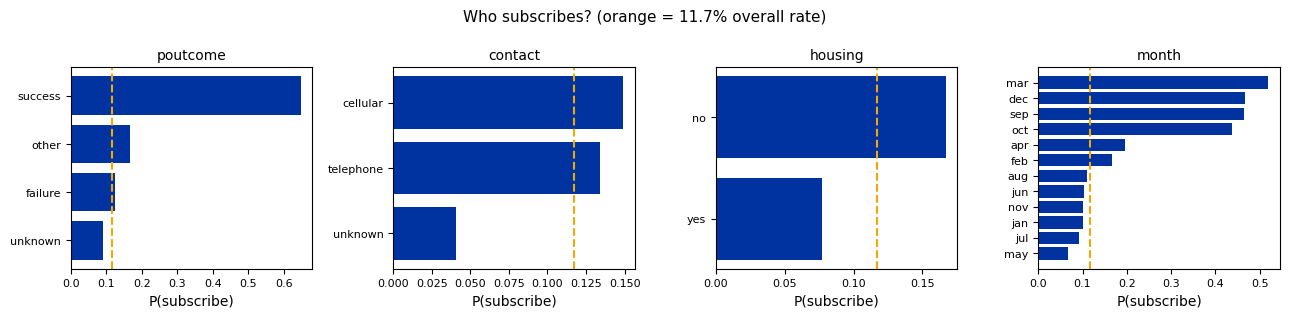

poutcome='success' and previously-contacted clients subscribe far above base rate;
'unknown' contact (no cellphone on file) sits well below it; strong month seasonality.


In [15]:
# subscription rate by a few informative categoricals (orange line = 11.7% base rate)
eda_cats = ["poutcome", "contact", "housing", "month"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, c in zip(axes, eda_cats):
    r = df.groupby(c)["y"].mean().sort_values()
    ax.barh(r.index.astype(str), r.values, color=ARM_BLUE)
    ax.axvline(df["y"].mean(), color=ARM_ORANGE, ls="--", lw=1.5)
    ax.set_title(c, fontsize=10); ax.set_xlabel("P(subscribe)"); ax.tick_params(labelsize=8)
fig.suptitle("Who subscribes? (orange = 11.7% overall rate)", fontsize=11)
plt.tight_layout(); plt.show()
print("poutcome='success' and previously-contacted clients subscribe far above base rate;")
print("'unknown' contact (no cellphone on file) sits well below it; strong month seasonality.")

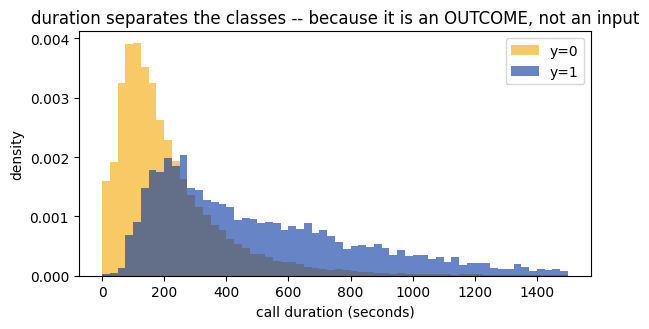

median duration: non-subscribers 164s vs subscribers 426s


In [16]:
# WHY duration leaks: subscribers stay on the line much longer -- but you only learn the
# duration AFTER the call, so it cannot help decide whom to call in the first place.
fig, ax = plt.subplots(figsize=(6.2, 3.4))
for lab, c in [(0, ARM_ORANGE), (1, ARM_BLUE)]:
    ax.hist(df.loc[df["y"] == lab, "duration"], bins=60, range=(0, 1500),
            density=True, alpha=0.6, color=c, label=f"y={lab}")
ax.set_xlabel("call duration (seconds)"); ax.set_ylabel("density")
ax.set_title("duration separates the classes -- because it is an OUTCOME, not an input")
ax.legend(); plt.tight_layout(); plt.show()
print(f"median duration: non-subscribers {df.loc[df.y==0,'duration'].median():.0f}s "
      f"vs subscribers {df.loc[df.y==1,'duration'].median():.0f}s")

**Data quirks (look before you model).** Two things to handle:

- `pdays = -1` is a **sentinel** meaning "this client was never contacted in a previous campaign" — not a real "-1 days". Feeding it raw to a scaler is wrong. We add a `was_contacted_before` flag and set those `pdays` to 0.
- Several categorical columns contain an `"unknown"` level (e.g. `contact`, `poutcome`). That is a legitimate category — one-hot encoding will just give it its own column.

In [17]:
print(f"never contacted before (pdays == -1): {(df['pdays'] == -1).mean():.1%}")
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)
df.loc[df["pdays"] == -1, "pdays"] = 0

for c in ["job", "education", "contact", "poutcome"]:
    share = (df[c] == "unknown").mean()
    if share:
        print(f"  '{c}': {share:.1%} unknown")

never contacted before (pdays == -1): 81.7%
  'job': 0.6% unknown
  'education': 4.1% unknown
  'contact': 28.8% unknown
  'poutcome': 81.7% unknown


Define the column groups we will preprocess differently. (`duration` is included **for now** — Part 3 deals with it.)

In [18]:
df.nunique()

age                       77
job                       12
marital                    3
education                  4
default                    2
balance                 7168
housing                    2
loan                       2
contact                    3
day                       31
month                     12
duration                1573
campaign                  48
pdays                    559
previous                  41
poutcome                   4
y                          2
was_contacted_before       2
dtype: int64

In [19]:
num_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous",
            "was_contacted_before"]
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact",
            "month", "poutcome"]
X = df.drop(columns="y")
y = df["y"].values
print(f"{len(num_cols)} numeric, {len(cat_cols)} categorical features")

8 numeric, 9 categorical features


## Part 2 — Split & a baseline to beat

We use **three** splits, not two:

- **train** — fit the model;
- **validation** — pick the threshold and check calibration;
- **test** — touched **once**, at the very end, for the number we report.

Tuning the threshold on the same data you report on would bias the result optimistically.

In [20]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)
print(f"train={len(y_tr)}, val={len(y_val)}, test={len(y_te)}")
print(f"positive rate preserved: {y_tr.mean():.3f} / {y_val.mean():.3f} / {y_te.mean():.3f}")

train=27126, val=9042, test=9043
positive rate preserved: 0.117 / 0.117 / 0.117


**The baseline.** `DummyClassifier` predicts the majority class. High accuracy, zero recall — the lecture's whole point, on real data.

In [21]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
print(f"dummy accuracy: {dummy.score(X_val, y_val):.3f}")
print(f"dummy recall:   {recall_score(y_val, dummy.predict(X_val)):.3f}")
print("High accuracy, catches nobody. Accuracy is the wrong lens here.")

dummy accuracy: 0.883
dummy recall:   0.000
High accuracy, catches nobody. Accuracy is the wrong lens here.


## Part 3 — Preprocess, then the leakage trap

**Preprocessing in a `Pipeline`** so scaling/encoding are fit on *train only* (no leakage):
`StandardScaler` for numerics, `OneHotEncoder(drop="first")` for categoricals.

In [22]:
def make_pipe(numeric, class_weight=None, penalty="l2", C=1.0, solver="lbfgs"):
    pre = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first", handle_unknown="error"), cat_cols),
    ])
    clf = LogisticRegression(max_iter=2000, class_weight=class_weight,
                             penalty=penalty, C=C, solver=solver)
    return Pipeline([("pre", pre), ("clf", clf)])

**The leakage trap.** `duration` is the length of the call in seconds. You only know it
*after* the call has happened — so a model that uses it to decide *whom to call* is cheating.
Let's measure how much it inflates the score, then drop it.

val ROC AUC WITH duration (leaky):    0.902
val ROC AUC WITHOUT duration (honest): 0.762
leakage inflated the AUC by 0.140


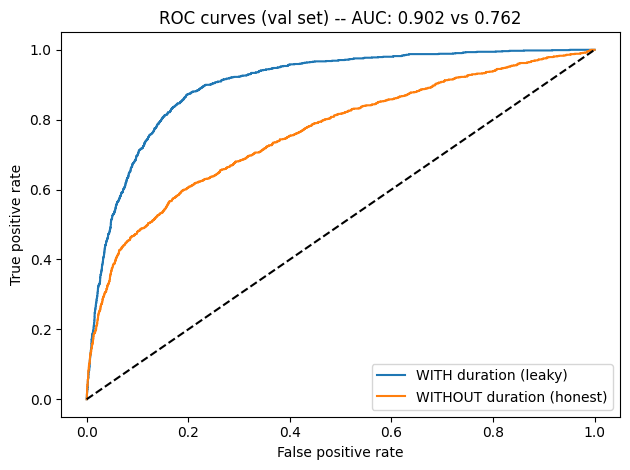

In [23]:
pipe_leaky = make_pipe(num_cols).fit(X_tr, y_tr)          # WITH duration
auc_leaky = roc_auc_score(y_val, pipe_leaky.predict_proba(X_val)[:, 1])

num_honest = [c for c in num_cols if c != "duration"]     # WITHOUT duration
pipe = make_pipe(num_honest).fit(X_tr, y_tr)
s_val = pipe.predict_proba(X_val)[:, 1]
auc_honest = roc_auc_score(y_val, s_val)

print(f"val ROC AUC WITH duration (leaky):    {auc_leaky:.3f}")
print(f"val ROC AUC WITHOUT duration (honest): {auc_honest:.3f}")
print(f"leakage inflated the AUC by {auc_leaky - auc_honest:.3f}")

# plot roc auc s for both
fpr_leaky, tpr_leaky, _ = roc_curve(y_val, pipe_leaky.predict_proba(X_val)[:, 1])
fpr_honest, tpr_honest, _ = roc_curve(y_val, s_val)
plt.plot(fpr_leaky, tpr_leaky, label="WITH duration (leaky)")
plt.plot(fpr_honest, tpr_honest, label="WITHOUT duration (honest)")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title(f"ROC curves (val set) -- AUC: {auc_leaky:.3f} vs {auc_honest:.3f}")
plt.legend(); plt.tight_layout();


> **Takeaway.** The leaky model looks better, but its score is a fantasy — at decision time
> you don't have `duration`. We keep the **honest** model (`pipe`, no `duration`) for everything below.

## Part 4 — Logistic regression & interpreting it

`pipe` is our fitted logistic regression. Logreg's superpower is interpretability:
`exp(coef)` is an **odds ratio**. Because the numerics are standardized, their odds ratios are
**per one standard deviation** (handy: they're directly comparable). One-hot columns are 0/1,
so their odds ratio is "this category vs the dropped reference" — so print the reference too.

dropped reference category per feature: {'job': 'admin.', 'marital': 'divorced', 'education': 'primary', 'default': 'no', 'housing': 'no', 'loan': 'no', 'contact': 'cellular', 'month': 'apr', 'poutcome': 'failure'}


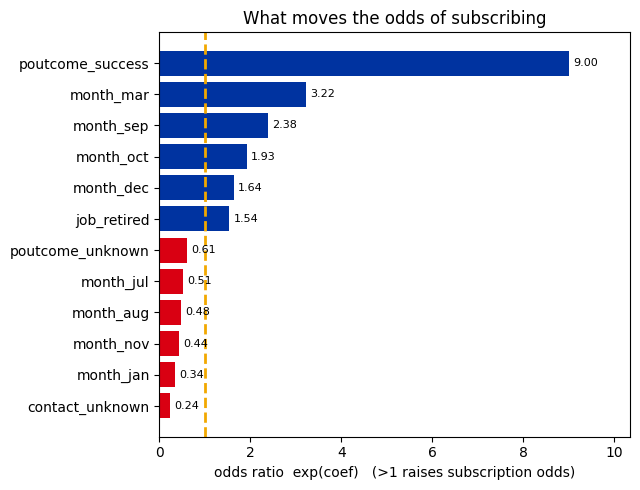

Strongest positive: {'month_sep': 2.38, 'month_mar': 3.22, 'poutcome_success': 9.0}
Strongest negative: {'contact_unknown': 0.24, 'month_jan': 0.34, 'month_nov': 0.44}


In [24]:
ohe = pipe.named_steps["pre"].named_transformers_["cat"]
feat_names = num_honest + list(ohe.get_feature_names_out(cat_cols))
coef = pipe.named_steps["clf"].coef_.ravel()
odds = pd.Series(np.exp(coef), index=feat_names).sort_values()

refs = {c: list(cats)[0] for c, cats in zip(cat_cols, ohe.categories_)}
print("dropped reference category per feature:", refs)

top = pd.concat([odds.head(6), odds.tail(6)])
fig, ax = plt.subplots(figsize=(6.5, 5))
colors = [ARM_RED if v < 1 else ARM_BLUE for v in top.values]
ax.barh(range(len(top)), top.values, color=colors)
ax.axvline(1, color=ARM_ORANGE, lw=2, ls="--")
ax.set_yticks(range(len(top)), top.index)
ax.set_xlabel("odds ratio  exp(coef)   (>1 raises subscription odds)")
ax.set_title("What moves the odds of subscribing")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=8)
ax.margins(x=0.15)
plt.tight_layout(); plt.show()

print("Strongest positive:", odds.tail(3).round(2).to_dict())
print("Strongest negative:", odds.head(3).round(2).to_dict())

> **Caveat.** These are **standardized** (per-SD) odds ratios — great for comparing feature
> strength, but *not* "per extra euro / per extra year". For per-unit odds ratios you would fit
> on the raw, unscaled features.

## Part 5 — The right metric, then the operating point

At 11% positives, **accuracy and ROC overstate**. Report **PR AUC (average precision)** alongside
ROC, and read precision/recall at an operating point.

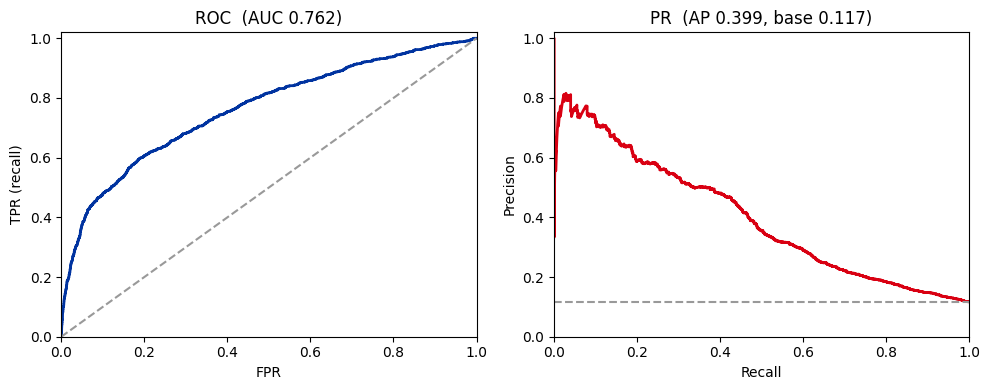

ROC AUC 0.762  vs  PR AUC 0.399  (PR is the honest one here).


In [25]:
roc_auc = roc_auc_score(y_val, s_val)
pr_auc = average_precision_score(y_val, s_val)
base = y_val.mean()
fpr, tpr, _ = roc_curve(y_val, s_val)
prec, rec, _ = precision_recall_curve(y_val, s_val)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
a1.plot(fpr, tpr, color=ARM_BLUE, lw=2); a1.plot([0, 1], [0, 1], "--", color="0.6")
a1.set_xlabel("FPR"); a1.set_ylabel("TPR (recall)"); a1.set_title(f"ROC  (AUC {roc_auc:.3f})")
a2.plot(rec, prec, color=ARM_RED, lw=2); a2.axhline(base, ls="--", color="0.6")
a2.set_xlabel("Recall"); a2.set_ylabel("Precision"); a2.set_title(f"PR  (AP {pr_auc:.3f}, base {base:.3f})")
for a in (a1, a2): a.set_xlim(0, 1); a.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()
print(f"ROC AUC {roc_auc:.3f}  vs  PR AUC {pr_auc:.3f}  (PR is the honest one here).")

**Choose the threshold by cost, not by 0.5.** Suppose a wasted call costs **€5** and a missed
subscriber costs **€100** (lost net value). We count only the **error** costs (a made sale nets
value minus the call); minimise expected error cost on validation.
Because we did **not** reweight the classes, the probabilities are honest, so the empirical
optimum should land near the closed-form `C_FP / (C_FN + C_FP)`.

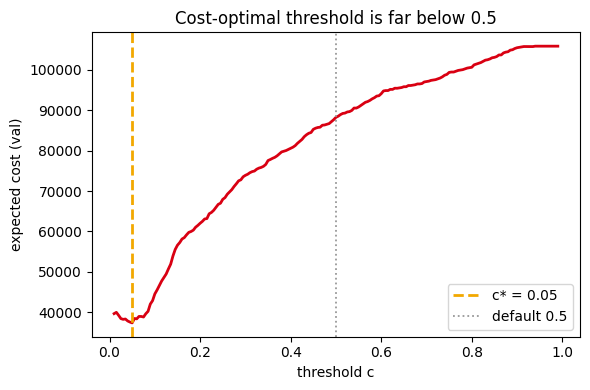

c* = 0.050  (closed-form 0.048); cost at c* = 37,415 vs at 0.5 = 88,215


In [26]:
C_FP, C_FN = 5, 100
ts = np.linspace(0.01, 0.99, 197)

def total_cost(yv, sv, t):
    pred = sv >= t
    fp = np.sum(pred & (yv == 0)); fn = np.sum((~pred) & (yv == 1))
    return C_FP * fp + C_FN * fn

costs = np.array([total_cost(y_val, s_val, t) for t in ts])
c_star = ts[int(np.argmin(costs))]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ts, costs, color=ARM_RED, lw=2)
ax.axvline(c_star, color=ARM_ORANGE, lw=2, ls="--", label=f"c* = {c_star:.2f}")
ax.axvline(0.5, color="0.6", lw=1.3, ls=":", label="default 0.5")
ax.set_xlabel("threshold c"); ax.set_ylabel("expected cost (val)")
ax.set_title("Cost-optimal threshold is far below 0.5"); ax.legend()
plt.tight_layout(); plt.show()
print(f"c* = {c_star:.3f}  (closed-form {C_FP/(C_FN+C_FP):.3f}); "
      f"cost at c* = {costs.min():,.0f} vs at 0.5 = {total_cost(y_val, s_val, 0.5):,.0f}")

## Part 6 — Are the probabilities trustworthy? (calibration)

A cost decision (and any "this client has an 80% chance" statement) only means something if the
probabilities are **calibrated**. Logistic regression minimises log-loss (a proper scoring rule),
so it is usually well calibrated — let's check, and then see what `class_weight="balanced"` does to it.

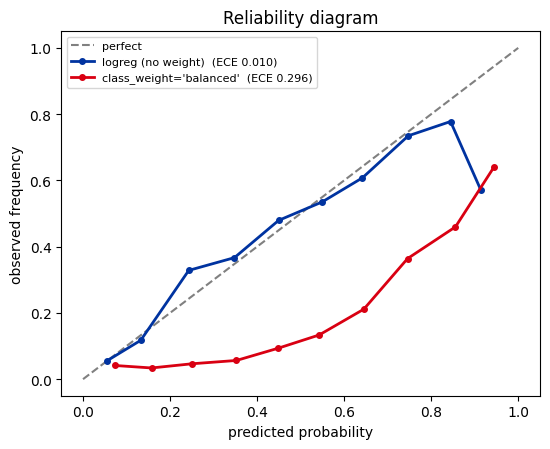

no-weight mean prediction 0.117  vs  true rate 0.117
balanced  mean prediction 0.413  -- inflated, so it would need re-calibration.


In [27]:
def ece(yv, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    return sum((m.sum()/len(p)) * abs(yv[m].mean() - p[m].mean())
               for m in (idx == b for b in range(n_bins)) if m.sum())

# the cautionary comparison: same model, but class_weight="balanced"
pipe_bal = make_pipe(num_honest, class_weight="balanced").fit(X_tr, y_tr)
s_val_bal = pipe_bal.predict_proba(X_val)[:, 1]

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot([0, 1], [0, 1], "--", color="0.5", label="perfect")
for name, p, c in [("logreg (no weight)", s_val, ARM_BLUE),
                   ("class_weight='balanced'", s_val_bal, ARM_RED)]:
    frac, mean = calibration_curve(y_val, p, n_bins=10, strategy="uniform")
    ax.plot(mean, frac, "-o", color=c, lw=2, ms=4, label=f"{name}  (ECE {ece(y_val, p):.3f})")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Reliability diagram"); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
print(f"no-weight mean prediction {s_val.mean():.3f}  vs  true rate {y_val.mean():.3f}")
print(f"balanced  mean prediction {s_val_bal.mean():.3f}  -- inflated, so it would need re-calibration.")

> **Takeaway.** The plain logreg is well calibrated, so the cost-optimal threshold above is
> meaningful. `class_weight="balanced"` improves nothing here and **distorts the probabilities**
> (it inflates them far above the 11% base rate) — if you used it you would have to re-calibrate.
> That's why we handled the imbalance with the **threshold**, not by reweighting.

**Fixing a decalibrated model — the tool for when you *do* reweight.** We rejected `class_weight` here because the plain logreg was already calibrated. But many models aren't (a reweighted logreg, and later boosted trees or SVMs). Deck [14]'s answer: don't retrain — learn a small post-hoc **isotonic** map from the raw scores to true frequencies with `CalibratedClassifierCV`, fit by CV on held-out data. Watch it undo the damage `class_weight` did.

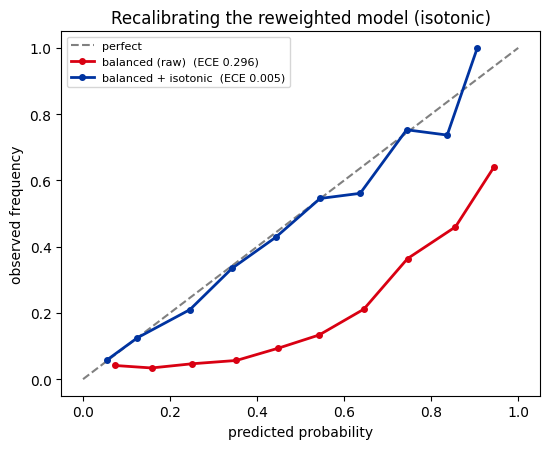

mean prediction:  balanced 0.413 -> +isotonic 0.118 (true rate 0.117)
ECE:              balanced 0.296 -> +isotonic 0.005


In [28]:
from sklearn.calibration import CalibratedClassifierCV

# recalibrate the reweighted model: an isotonic map fit by CV on the training data
# (each fold's calibrator sees data its base model did not train on -- the golden rule)
cal_bal = CalibratedClassifierCV(
    make_pipe(num_honest, class_weight="balanced"), method="isotonic", cv=5
).fit(X_tr, y_tr)
s_val_bal_cal = cal_bal.predict_proba(X_val)[:, 1]

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot([0, 1], [0, 1], "--", color="0.5", label="perfect")
for name, p, c in [("balanced (raw)", s_val_bal, ARM_RED),
                   ("balanced + isotonic", s_val_bal_cal, ARM_BLUE)]:
    frac, mean = calibration_curve(y_val, p, n_bins=10, strategy="uniform")
    ax.plot(mean, frac, "-o", color=c, lw=2, ms=4, label=f"{name}  (ECE {ece(y_val, p):.3f})")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Recalibrating the reweighted model (isotonic)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
print(f"mean prediction:  balanced {s_val_bal.mean():.3f} -> +isotonic {s_val_bal_cal.mean():.3f} "
      f"(true rate {y_val.mean():.3f})")
print(f"ECE:              balanced {ece(y_val, s_val_bal):.3f} -> +isotonic {ece(y_val, s_val_bal_cal):.3f}")

> **Takeaway.** Isotonic pulls the inflated scores back onto the diagonal — ECE collapses (≈0.30 → ≈0.005) and the mean prediction returns to ~11%. Decalibration is **fixable**: any model whose *ranking* you trust but whose *probability values* you don't (reweighted logreg, and later boosted trees / SVMs) can be wrapped this way, fit on held-out data. We still didn't *need* it here — Part 8 shows why reweighting wasn't worth it in the first place.

## Part 7 — Sealed-test evaluation & model card

Now, and only now, touch the test set: apply the honest pipeline at `c*` **once**.
(For an actual deployment you would refit on train+val before shipping; we keep the train-only
model so this test estimate stays honest.)

TEST  PR AUC        : 0.415
TEST  recall  @ c*  : 0.910
TEST  precision @ c*: 0.145
TEST  F1       @ c* : 0.250
TEST  cost @ c* = 37,855  vs  @0.5 = 88,070  (saving 57%)


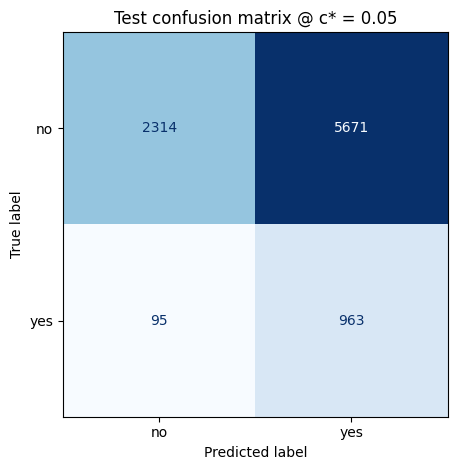

In [29]:
s_te = pipe.predict_proba(X_te)[:, 1]
pred_te = (s_te >= c_star).astype(int)

print(f"TEST  PR AUC        : {average_precision_score(y_te, s_te):.3f}")
print(f"TEST  recall  @ c*  : {recall_score(y_te, pred_te):.3f}")
print(f"TEST  precision @ c*: {precision_score(y_te, pred_te):.3f}")
print(f"TEST  F1       @ c* : {f1_score(y_te, pred_te):.3f}")
cost_star = C_FP*np.sum(pred_te & (y_te==0)) + C_FN*np.sum((pred_te==0) & (y_te==1))
cost_half = (lambda p: C_FP*np.sum(p & (y_te==0)) + C_FN*np.sum((p==0) & (y_te==1)))((s_te>=0.5).astype(int))
print(f"TEST  cost @ c* = {cost_star:,.0f}  vs  @0.5 = {cost_half:,.0f}  "
      f"(saving {100*(1-cost_star/cost_half):.0f}%)")

ConfusionMatrixDisplay(confusion_matrix(y_te, pred_te),
                       display_labels=["no", "yes"]).plot(cmap="Blues", colorbar=False)
plt.title(f"Test confusion matrix @ c* = {c_star:.2f}"); plt.tight_layout(); plt.show()

### Model card

| Field | Value |
|---|---|
| **Task** | Predict term-deposit subscription (binary), to target a phone campaign |
| **Data** | UCI Bank Marketing, 45,211 clients, 11.7% positive |
| **Leakage handled** | Dropped `duration` (known only after the call); `pdays = -1` sentinel → flag + 0 |
| **Model** | Logistic regression (L2), standardized numerics + one-hot categoricals, **no** class reweighting |
| **Headline metric** | PR AUC (average precision) — ROC overstates on 11% positives |
| **Operating point** | Threshold `c*` chosen by expected cost (call €5, missed sale €100) on validation, far below 0.5 |
| **Calibration** | Well calibrated (low ECE); reweighting was rejected because it distorts probabilities |
| **Limitations** | One validation split (not nested CV); costs are illustrative; campaign/contact features are time-specific |

> **One-line takeaway:** at 11% positives the model is only useful once you (1) drop the leaky
> feature, (2) judge it with PR not accuracy, and (3) move the threshold to match the cost of a
> missed customer — exactly the L11→L12→L13 arc.

## Part 8 — Would reweighting or resampling have helped?

We handled the 11% imbalance with the **metric** (PR AUC) and the **cost threshold** — never touching the classes. Deck [15] offers the heavier tools: **class weights** and **resampling** (`RandomOverSampler`, and **SMOTENC** for our 9 categorical columns). Do they actually beat the baseline?

The honest test is **PR AUC in 5-fold CV**, with every resampler fit **inside each fold** (`imblearn.Pipeline`) — resampling before the split leaks synthetic points across train/test and gives a fantasy score.

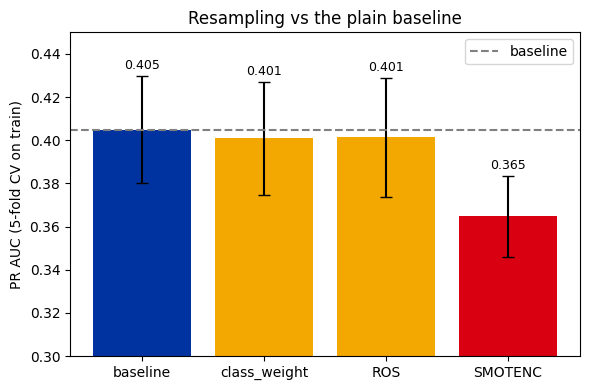

  baseline      PR-AUC 0.405 +/- 0.025
  class_weight  PR-AUC 0.401 +/- 0.026
  ROS           PR-AUC 0.401 +/- 0.027
  SMOTENC       PR-AUC 0.365 +/- 0.019


In [30]:
from imblearn.over_sampling import SMOTENC, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score

def pre_ct():   # same preprocessing; ignore a rare category that may be absent from a fold
    return ColumnTransformer([
        ("num", StandardScaler(), num_honest),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)])

cat_idx = [X_tr.columns.get_loc(c) for c in cat_cols]      # SMOTENC needs categorical positions
lr = lambda **k: LogisticRegression(max_iter=2000, **k)
approaches = {
    "baseline":     Pipeline([("pre", pre_ct()), ("clf", lr())]),
    "class_weight": Pipeline([("pre", pre_ct()), ("clf", lr(class_weight="balanced"))]),
    "ROS":          ImbPipeline([("s", RandomOverSampler(random_state=SEED)), ("pre", pre_ct()), ("clf", lr())]),
    "SMOTENC":      ImbPipeline([("s", SMOTENC(categorical_features=cat_idx, random_state=SEED)), ("pre", pre_ct()), ("clf", lr())]),
}
cv_pr = {n: cross_val_score(p, X_tr, y_tr, scoring="average_precision", cv=5) for n, p in approaches.items()}

names = list(cv_pr)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(names, [cv_pr[n].mean() for n in names], yerr=[cv_pr[n].std() for n in names],
              color=[ARM_BLUE, ARM_ORANGE, ARM_ORANGE, ARM_RED], capsize=4)
ax.axhline(cv_pr["baseline"].mean(), ls="--", color="0.5", label="baseline")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylabel("PR AUC (5-fold CV on train)"); ax.set_ylim(0.30, 0.45)
ax.set_title("Resampling vs the plain baseline"); ax.legend(); plt.tight_layout(); plt.show()
for n in names:
    print(f"  {n:13s} PR-AUC {cv_pr[n].mean():.3f} +/- {cv_pr[n].std():.3f}")

In [31]:
# ...and what each does to the PROBABILITIES: fit on train, measure on validation
print(f"{'approach':13s} {'val PR-AUC':>10s} {'ECE':>7s} {'mean pred':>10s}   (true rate {y_val.mean():.3f})")
for n, p in approaches.items():
    sv = p.fit(X_tr, y_tr).predict_proba(X_val)[:, 1]
    print(f"{n:13s} {average_precision_score(y_val, sv):>10.3f} {ece(y_val, sv):>7.3f} {sv.mean():>10.3f}")

approach      val PR-AUC     ECE  mean pred   (true rate 0.117)
baseline           0.399   0.010      0.117
class_weight       0.398   0.296      0.413
ROS                0.399   0.297      0.414
SMOTENC            0.359   0.236      0.353


> **Takeaway — *why* resampling doesn't beat the baseline here.** Three reasons:
>
> 1. **The minority isn't actually starved.** 11% of 27k is ~3,200 positive training examples — plenty for logreg to learn the boundary. Resampling helps when the minority region is so *sparse* the model can't fit it at all; that is not this data.
> 2. **Rebalancing can't improve the *ranking*.** Class weights and oversampling essentially change the class *prior*, which just slides the implicit decision threshold — but **PR-AUC is threshold-independent**, so a pure prior shift leaves the ordering (and thus PR-AUC) unchanged. We already control the operating point *directly and more precisely* with the cost threshold.
> 3. **They cost you calibration.** Inflating the positive prior pushes every probability up: ECE jumps ≈0.01 → 0.24–0.30 and mean prediction 11% → 35–41%, so you'd have to recalibrate (Part 6) just to get back where the plain model already was.
>
> So `class_weight` and ROS match the baseline within CV noise, and SMOTENC is a touch *worse* (its synthetic points blur an already-fuzzy boundary). The **threshold did the job for free** — resampling earns its keep only when the *fit itself* is starved, not when only the operating point needs moving. (Exactly deck [15]'s thesis, on our own data.)

## Going further (optional)

**A. Lift by decile — "we can only call the top X%."** Rank clients by score, split into **10 equal deciles** (decile 1 = the highest-scoring 10%), and see how concentrated the subscribers are. (Use the **validation** set — the test set is already spent.)

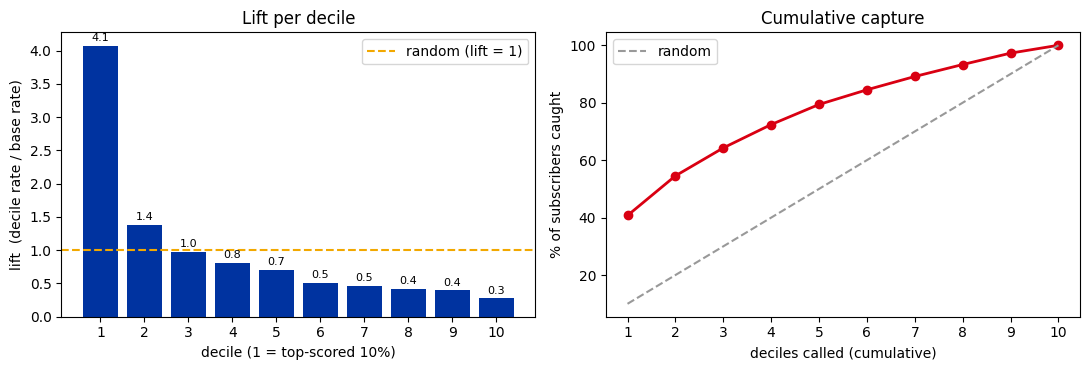

        size  subs   rate   lift  cum_capture
decile                                       
1        905   431  0.476  4.070        0.407
2        905   146  0.161  1.379        0.545
3        905   103  0.114  0.973        0.643
4        905    86  0.095  0.812        0.724
5        905    74  0.082  0.699        0.794
6        905    54  0.060  0.510        0.845
7        905    49  0.054  0.463        0.891
8        905    44  0.049  0.416        0.933
9        905    42  0.046  0.397        0.973
10       897    29  0.032  0.276        1.000

Top decile: 4.1x lift; top 2 deciles catch 55% of all subscribers.


In [32]:
order = np.argsort(-s_val)
n = len(y_val)
decile = np.repeat(np.arange(1, 11), n // 10 + 1)[:n]          # 1 = top-scored 10%
base = y_val.mean()
tab = pd.DataFrame({"decile": decile, "y": y_val[order]})
g = tab.groupby("decile")["y"].agg(size="size", subs="sum", rate="mean")
g["lift"] = g["rate"] / base
g["cum_capture"] = g["subs"].cumsum() / y_val.sum()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
bars = a1.bar(g.index, g["lift"], color=ARM_BLUE)
a1.axhline(1, color=ARM_ORANGE, ls="--", lw=1.5, label="random (lift = 1)")
a1.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)
a1.set_xlabel("decile (1 = top-scored 10%)"); a1.set_ylabel("lift  (decile rate / base rate)")
a1.set_title("Lift per decile"); a1.set_xticks(range(1, 11)); a1.legend()
a2.plot(range(1, 11), 100 * g["cum_capture"], "-o", color=ARM_RED, lw=2)
a2.plot([1, 10], [10, 100], "--", color="0.6", label="random")
a2.set_xlabel("deciles called (cumulative)"); a2.set_ylabel("% of subscribers caught")
a2.set_title("Cumulative capture"); a2.set_xticks(range(1, 11)); a2.legend()
plt.tight_layout(); plt.show()
print(g.round(3).to_string())
print(f"\nTop decile: {g.loc[1,'lift']:.1f}x lift; top 2 deciles catch "
      f"{100*g.loc[2,'cum_capture']:.0f}% of all subscribers.")

**B. Sparsity with L1.** How does an L1 penalty trade sparsity against performance as its strength varies? Sweep `C` (inverse regularization) and watch coefficients get driven to zero — and check the val PR-AUC barely moves.

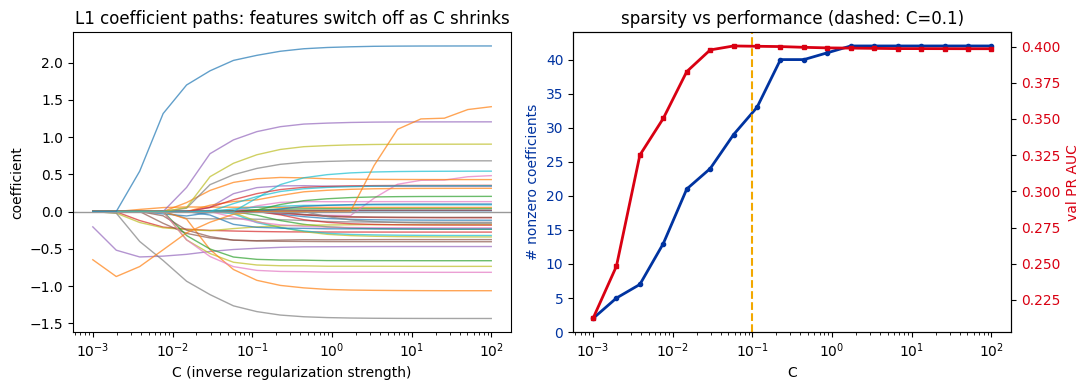

at C=0.1: 9/42 coefficients = 0; val PR AUC 0.400 (full model 0.399)
L1 drops a good chunk of columns with essentially no PR-AUC loss -- a cheaper, more readable model.


In [33]:
Cs = np.logspace(-3, 2, 18)
paths, n_nonzero, ap_l1 = [], [], []
for C in Cs:
    m = make_pipe(num_honest, penalty="l1", C=C, solver="liblinear").fit(X_tr, y_tr)
    w = m.named_steps["clf"].coef_.ravel()
    paths.append(w); n_nonzero.append(int(np.sum(w != 0)))
    ap_l1.append(average_precision_score(y_val, m.predict_proba(X_val)[:, 1]))
paths = np.array(paths)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
for k in range(paths.shape[1]):
    a1.plot(Cs, paths[:, k], lw=1, alpha=0.7)
a1.set_xscale("log"); a1.axhline(0, color="0.6", lw=1)
a1.set_xlabel("C (inverse regularization strength)"); a1.set_ylabel("coefficient")
a1.set_title("L1 coefficient paths: features switch off as C shrinks")
a2.plot(Cs, n_nonzero, "-o", color=ARM_BLUE, lw=2, ms=3)
a2.set_xscale("log"); a2.set_xlabel("C")
a2.set_ylabel("# nonzero coefficients", color=ARM_BLUE); a2.tick_params(axis="y", labelcolor=ARM_BLUE)
a2b = a2.twinx()
a2b.plot(Cs, ap_l1, "-s", color=ARM_RED, lw=2, ms=3)
a2b.set_ylabel("val PR AUC", color=ARM_RED); a2b.tick_params(axis="y", labelcolor=ARM_RED)
a2.axvline(0.1, color=ARM_ORANGE, ls="--"); a2.set_title("sparsity vs performance (dashed: C=0.1)")
plt.tight_layout(); plt.show()

i0 = int(np.argmin(np.abs(Cs - 0.1)))
print(f"at C=0.1: {paths.shape[1]-n_nonzero[i0]}/{paths.shape[1]} coefficients = 0; "
      f"val PR AUC {ap_l1[i0]:.3f} (full model {average_precision_score(y_val, s_val):.3f})")
print("L1 drops a good chunk of columns with essentially no PR-AUC loss -- a cheaper, more readable model.")